### Flagging vendor invoices for Manual Review

Objective: Predict whether a vendor invoice should be flagged for manaual approval based on abnormal, freight, or delivery patters, in order to reduce financial risk, imporve operational efficiency and prioritize human review where it adds the most value.

In [4]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import warnings
warnings.filterwarnings('ignore')

In [5]:
conn=sqlite3.connect("D:\My Desktop\AI\Invoice Intelligence Machine Learning Project\data\inventory.db")
tables=pd.read_sql_query("select name from sqlite_master where type='table'", conn)

In [6]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [7]:
for table in tables['name']:
    print("Table name: ", table)
    df=pd.read_sql_query(f'SELECT * FROM {table} limit 5', conn)
    display(df)

Table name:  purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name:  purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name:  vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name:  begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name:  end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [8]:
df=pd.read_sql_query("""
WITH purchase_agg AS(
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate)-julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
)

select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.freight,
(julianday(vi.InvoiceDate)-julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate)-julianday(vi.InvoiceDate)) AS days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay

FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber=pa.PONumber
 """, conn)

In [9]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [10]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [11]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [12]:
def create_invoice_risk_label(row):

    # INvoice total mismatch with item-level total
    if (abs(row["invoice_dollars"]-row["total_item_dollars"])>5):
        return 1

    # Abnormally high receiving delay 
    if row["avg_receiving_delay"]>10:
        return 1

    return 0

df["flag_invoice"]=df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

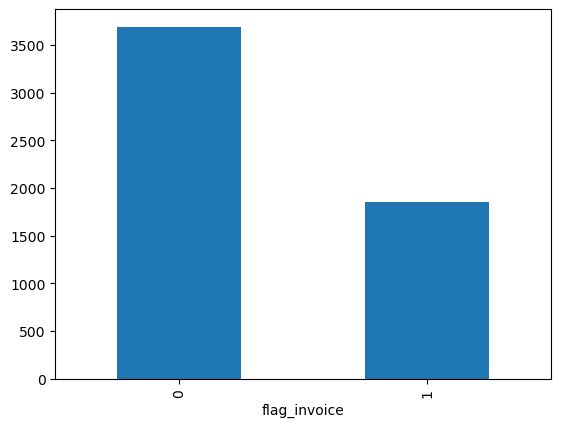

In [13]:
df['flag_invoice'].value_counts().plot(kind='bar')

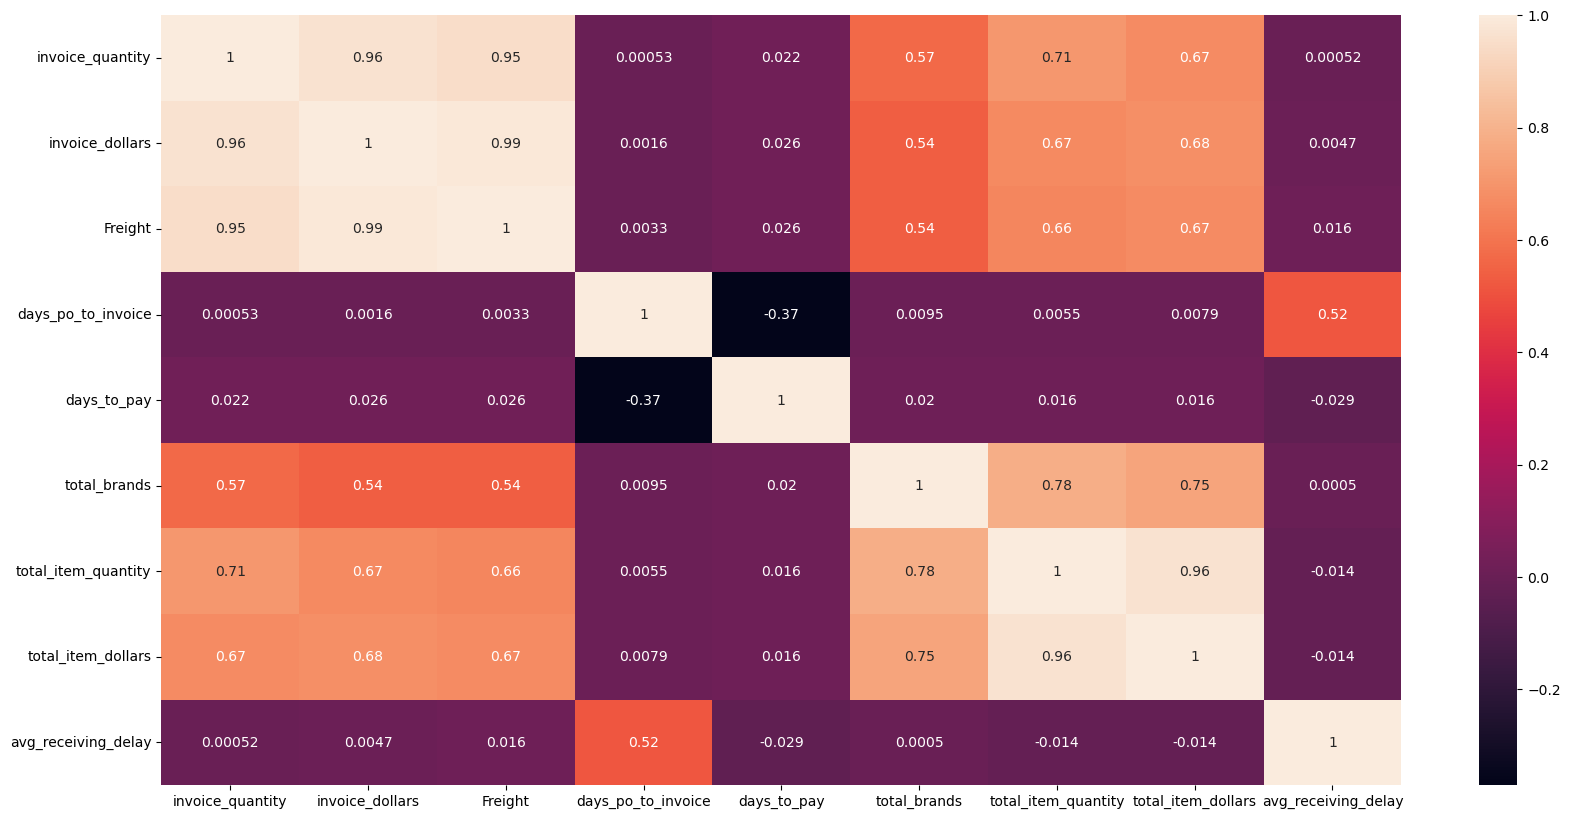

In [14]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.show()

In [15]:
flagged=df[df['flag_invoice']==1]
normal=df[df['flag_invoice']==0]

In [16]:
significant_features=[]
non_significant_features=[]
results=[]

In [17]:
metrics=['invoice_quantity', 'invoice_dollars', 'Freight',
         'days_po_to_invoice', 'days_to_pay', 'total_brands',
         'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [18]:
for metric in metrics:
    flagged_mean=flagged[metric].mean()
    normal_mean=normal[metric].mean()

    t_stat, p_value=ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value<0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p-value": p_value.round(3)
        })

    else:
        non_significant_features.append(metric)

In [19]:
non_significant_features

['days_to_pay', 'total_brands']

In [20]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [21]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p-value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p-value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p-value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p-value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p-value': 0.021},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p-value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p-value': 0.0}]

In [22]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
         'days_po_to_invoice',  'total_item_dollars']]
y = df['flag_invoice']

In [23]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,58073.0
std,14453.0,140234.0,714.0,3.0,140234.0
min,1.0,4.0,0.0,9.0,4.0
25%,83.0,968.0,5.0,14.0,968.0
50%,423.0,4765.0,25.0,16.0,4765.0
75%,5100.0,44587.0,230.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,23.0,1660436.0


In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [27]:
model1=LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2=DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3=RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [28]:
from sklearn.metrics import accuracy_score, classification_report
def evaluate_model(model, X_test, y_test, model_name):
    preds=model.predict(X_test)

    accuracy=accuracy_score(preds, y_test)
    print(f"\n Model Name: {model_name}")
    print(f"Accuracy: {accuracy: .2f}")
    print(f"Classification Report : {classification_report(preds, y_test)}")

In [29]:
evaluate_model(model1, X_test_scaled, y_test, 'LogisticRegression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


 Model Name: LogisticRegression
Accuracy:  0.66
Classification Report :               precision    recall  f1-score   support

           0       0.98      0.66      0.79      1076
           1       0.05      0.55      0.09        33

    accuracy                           0.66      1109
   macro avg       0.51      0.60      0.44      1109
weighted avg       0.95      0.66      0.77      1109


 Model Name: Decision Tree Classifier
Accuracy:  0.82
Classification Report :               precision    recall  f1-score   support

           0       0.88      0.85      0.86       748
           1       0.71      0.75      0.73       361

    accuracy                           0.82      1109
   macro avg       0.79      0.80      0.80      1109
weighted avg       0.82      0.82      0.82      1109


 Model Name: Random Forest Classifier
Accuracy:  0.87
Classification Report :               precision    recall  f1-score   support

           0       0.98      0.85      0.91       830
      

In [30]:
model3.feature_importances_

array([0.12668233, 0.17884252, 0.16659209, 0.08077371, 0.44710934])

In [31]:
feature_importance=pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)
feature_importance

,feature,importance
4,total_item_dollars,0.447109
1,invoice_dollars,0.178843
2,Freight,0.166592
0,invoice_quantity,0.126682
3,days_po_to_invoice,0.080774


### Hyper Parameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf=RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)
param_grid={
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}
scorer=make_scorer(f1_score)
grid_search=GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[708, 125],
       [ 17, 259]], dtype=int64)

In [ ]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[708, 122],
       [ 17, 262]], dtype=int64)

In [ ]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}